## BTSP on a linear track

* Linear track, single direction
* CA3: 8 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location
  * (2) 4 cells, with 2 receiving BTSP signals (near reward and start, respectively) 

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, neurons, run_manager, plot_util, util, params_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Define some functions

In [4]:
def learn(env_params=None, agent_params=None, CA3_PC_params=None, 
          CA1_params=None, num_rewards=200, max_num_steps=5000, 
          use_Hebbian=False, BTSP_after_num_target_reaches=5, 
          two_compartment=False):
    
    if env_params is None:
        env_params = params_util.get_env_params(environment="linear")
        
    if agent_params is None:
        agent_params = params_util.get_agent_params(environment="linear")

    if CA3_PC_params is None:
        CA3_PC_params = params_util.get_CA3_PC_params(environment="linear")

    if CA1_params is None:
        CA1_params = params_util.get_CA1_params(
            environment="linear", two_compartment=two_compartment, BTSP=True
        )

    print_vals = {
        "Environment scale": env_params["scale"],
        "Agent dt": agent_params["dt"],
        "Agent target position": agent_params["target_position"],
        "# CA3 PCs": CA3_PC_params["n"], 
        "# CA1s": CA1_params["n"], 
        "CA1 init at 0": CA1_params["init_weights_zero"], 
        "CA1 init scale": CA1_params["w_init_scale"], 
        "CA1 BTSP tau": CA1_params["BTSP_filter_tau"], 
        "# rewards": num_rewards, 
        "Max # steps": max_num_steps, 
        "Hebbian learning": use_Hebbian, 
        "BTSP occurs after X number of target reaches": BTSP_after_num_target_reaches,
        "Two-compartment": two_compartment,
    }
    print_vals = [
        f"{name:16}: {value}" for name, value in print_vals.items()
    ]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env, Ag, CA3_PCs, CA1s = run_manager.learn_1D_BTSP(
        env_params,
        agent_params,
        CA3_PC_params,
        CA1_params,
        num_rewards=num_rewards,
        max_num_steps=max_num_steps,
        use_Hebbian=use_Hebbian,
        BTSP_after_num_target_reaches=BTSP_after_num_target_reaches,
        two_compartment=two_compartment,
    )
    
    return Env, Ag, CA3_PCs, CA1s

## Reload

In [36]:
import importlib
importlib.reload(agent)
importlib.reload(neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

## Only 1 CA1 neuron

In [69]:
NUM_REWARDS = 8
MAX_NUM_STEPS = 5000
USE_HEBBIAN = False

CA1_params_one = params_util.get_CA1_params(
    n=1, environment="linear", 
    two_compartment=False, BTSP=True, 
    init_weights_zero=False,
    w_init_loc=0.02, # ensure initial weights are normalized according to regularization_alpha also ???
    w_init_scale=0,
    BTSP_filter_tau=2,
    BTSP_lr_fact=300, # extremely high...
    lr=5e-5,
    apply_Ojas_rule=False, # WAS TOO WEAK...
    normalize_weights_divisively=True,
    regularization_alpha=10, # used very high regularization...
)

Environment scale: 3.0
Agent dt        : 0.1
Agent target position: 2.2
# CA3 PCs       : 32
# CA1s          : 1
CA1 init at 0   : False
CA1 init scale  : 0
CA1 BTSP tau    : 2
# rewards       : 8
Max # steps     : 5000
Hebbian learning: False
BTSP occurs after X number of target reaches: 4
Two-compartment : False



 40%|███████████████▏                      | 1994/5000 [00:05<00:08, 372.92it/s]


Trajectory lengths (8) to date: 24.94 +/- 3.93 sec each
Trajectory lengths (8) to date: 249.38 +/- 39.34 steps each


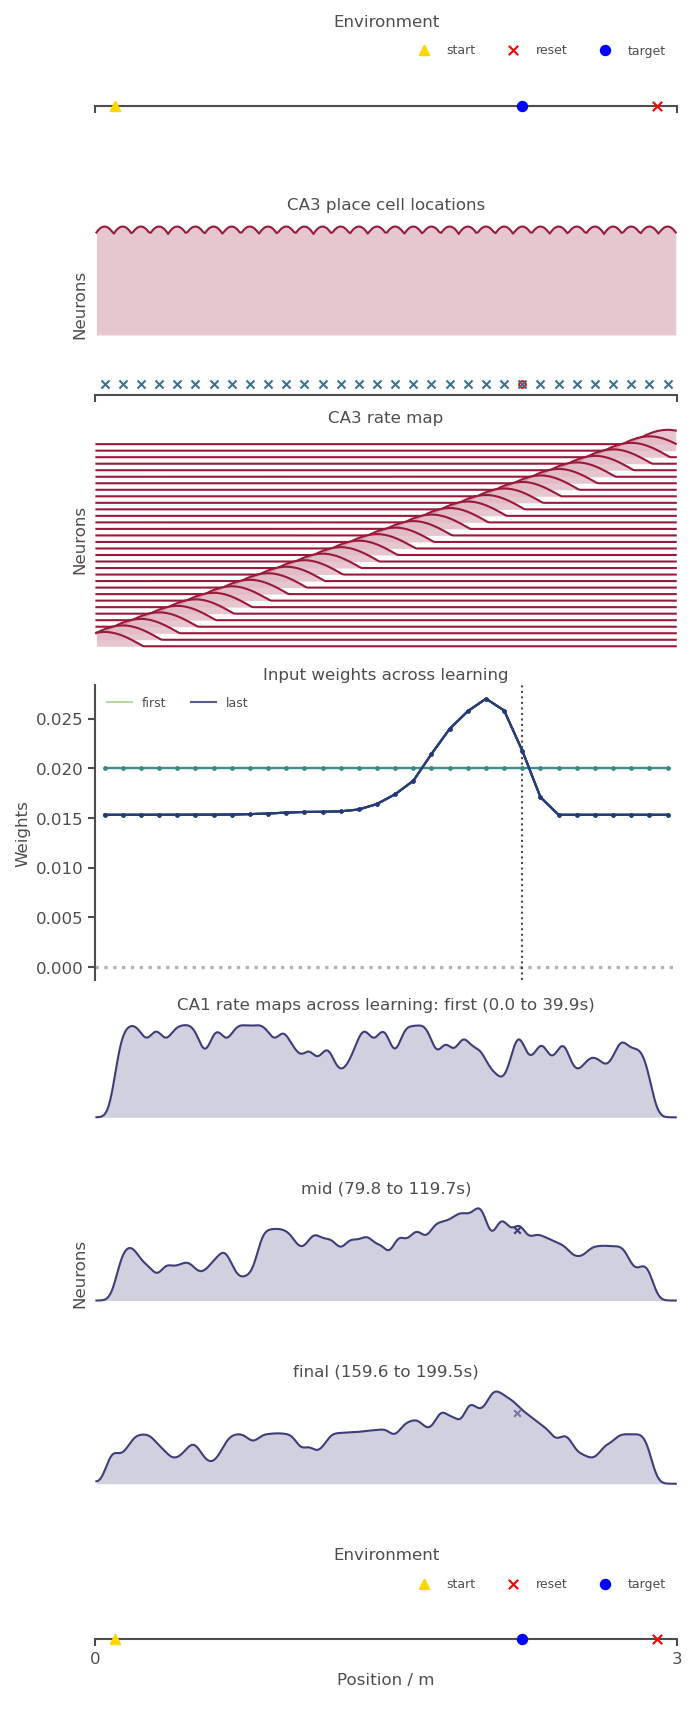

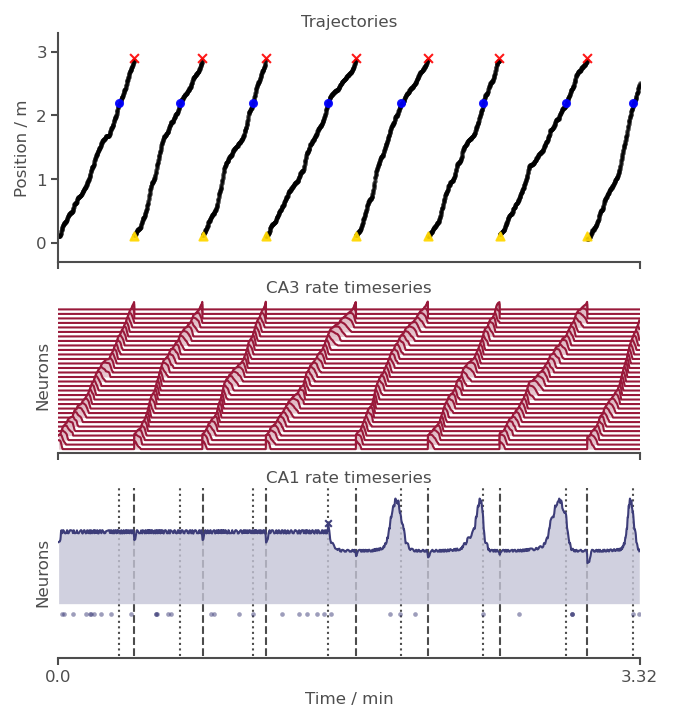

In [70]:
Env, Ag, CA3_PCs, CA1s = learn(
    CA1_params=CA1_params_one, 
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_after_num_target_reaches=4,
    two_compartment=False,
)

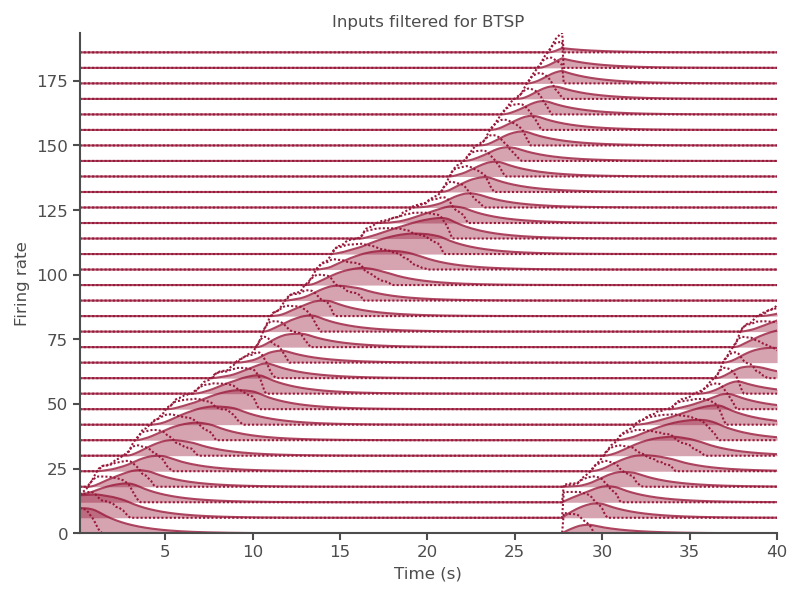

In [64]:
CA1s.plot_filtered_for_BTSP("CA3_PCs", t_end=40);

## Multiple CA1 neurons

In [20]:
NUM_REWARDS = 16
MAX_NUM_STEPS = 5000
USE_HEBBIAN = True

CA1_params_mult = params_util.get_CA1_params(
    n=4, environment="linear", 
    two_compartment=False, BTSP=True, 
    init_weights_zero=False,
    w_init_loc=0.04,
    w_init_scale=0,
    BTSP_filter_tau=2,
    BTSP_lr_fact=100,
    lr=1e-5,
    apply_Ojas_rule=True
)

Environment scale: 3.0
Agent dt        : 0.1
Agent target position: 2.2
# CA3 PCs       : 32
# CA1s          : 4
CA1 init at 0   : False
CA1 init scale  : 0
CA1 BTSP tau    : 2
# rewards       : 16
Max # steps     : 5000
Hebbian learning: True
BTSP occurs after X number of target reaches: 5
Two-compartment : False



 82%|███████████████████████████████       | 4094/5000 [00:09<00:01, 453.45it/s]


Trajectory lengths (16) to date: 25.59 +/- 3.17 sec each
Trajectory lengths (16) to date: 255.94 +/- 31.72 steps each


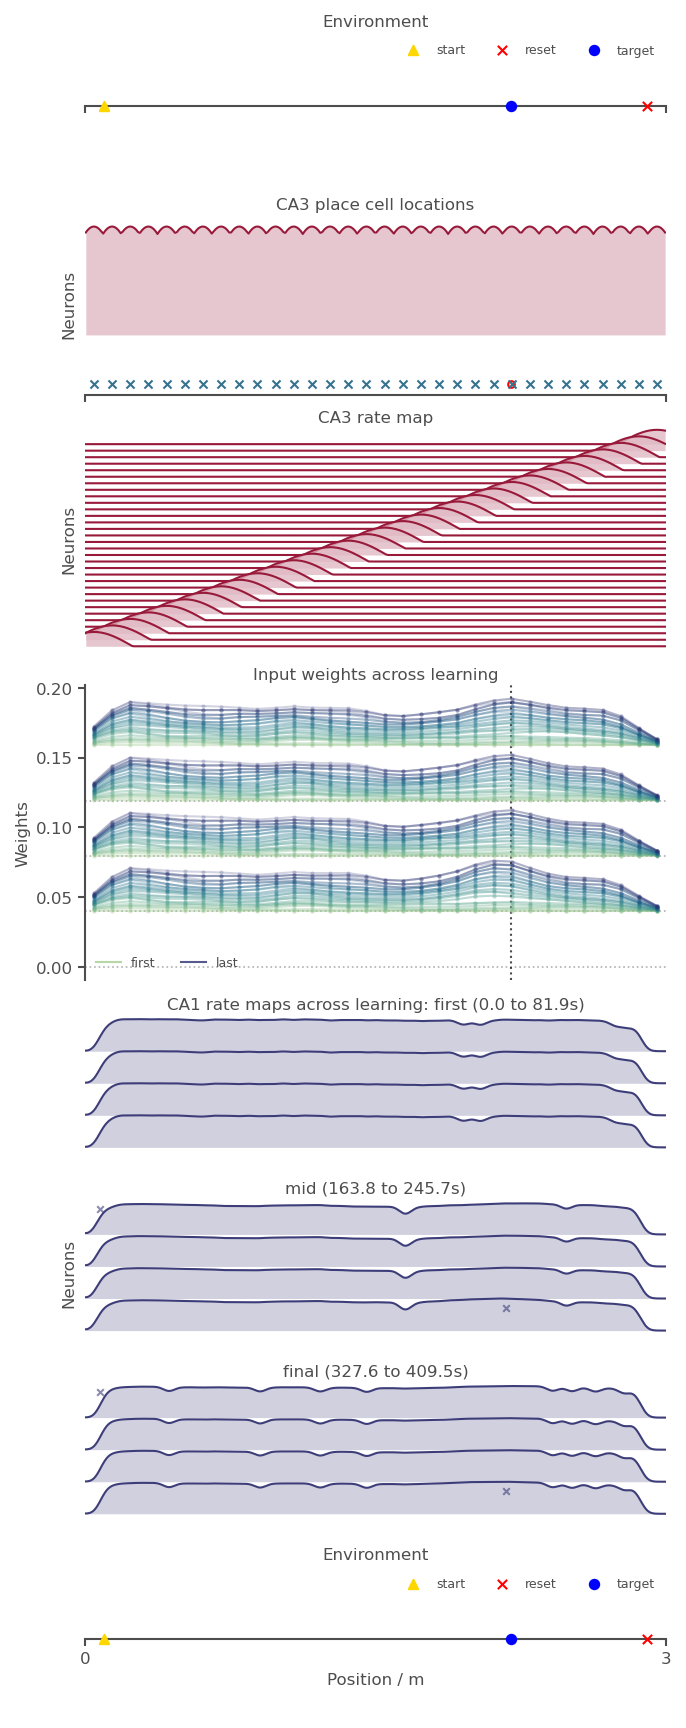

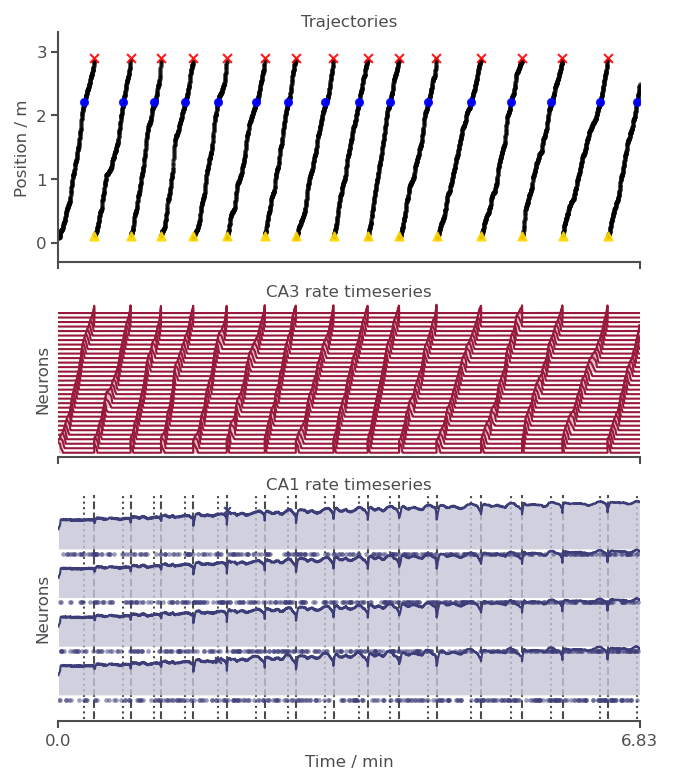

In [21]:
Env, Ag, CA3_PCs, CA1s = learn(
    CA1_params=CA1_params_mult,
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_after_num_target_reaches=5,
    two_compartment=False,
)

## BTSP filtered inputs

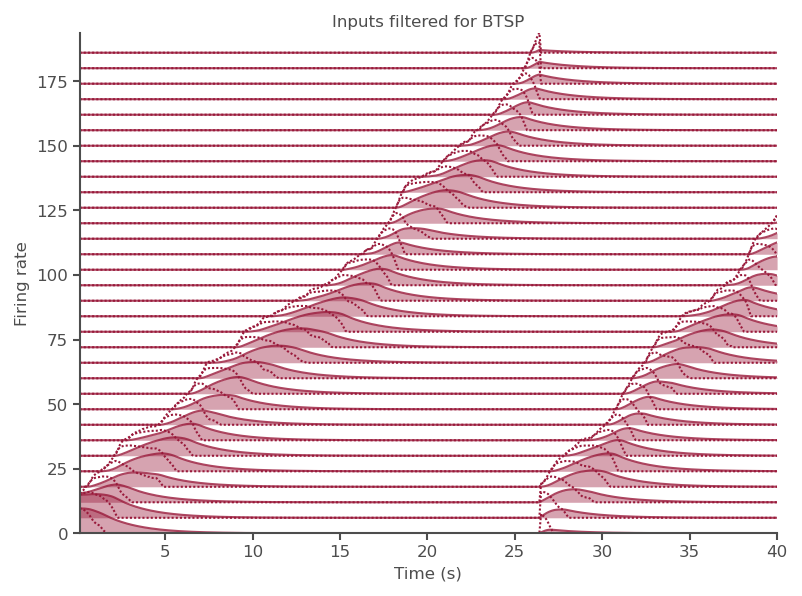

In [14]:
CA1s.plot_filtered_for_BTSP("CA3_PCs", t_start=0, t_end=40);

## BTSP independent

In [12]:
from ratinabox import Environment, PlaceCells

import importlib
importlib.reload(neurons.learning_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [13]:
DT = params_util.DT

env_params = params_util.get_env_params(
    boundary_conditions="periodic", # to avoid receptor binding discontinuity
)

agent_params = params_util.get_agent_params(dt=DT)

CA3_PC_params = params_util.get_CA3_PC_params(dt=DT)

CA1_params = params_util.get_CA1_params(
    n=1, environment="linear", 
    two_compartment=False, BTSP=True, 
    init_weights_zero=False,
    w_init_scale=0.2, # set fairly small
    BTSP_filter_tau=2,
    BTSP_lr_fact=30,
    single_BTSP=True,
    lr=1e-4,
    apply_Ojas_rule=True
)

/home/colleen/Documents/postdoc/RatInABox/ratinabox/utils.py:869: UserWarning: Found 1 unexpected params key(s) while initializing PlaceCells object: 'dt'.
If you intended to set this parameter, ignore this message. To see all default parameters for this class call PlaceCells.get_all_default_params().
  warnings.warn(
100%|████████████████████████████████████████| 500/500 [00:02<00:00, 184.82it/s]


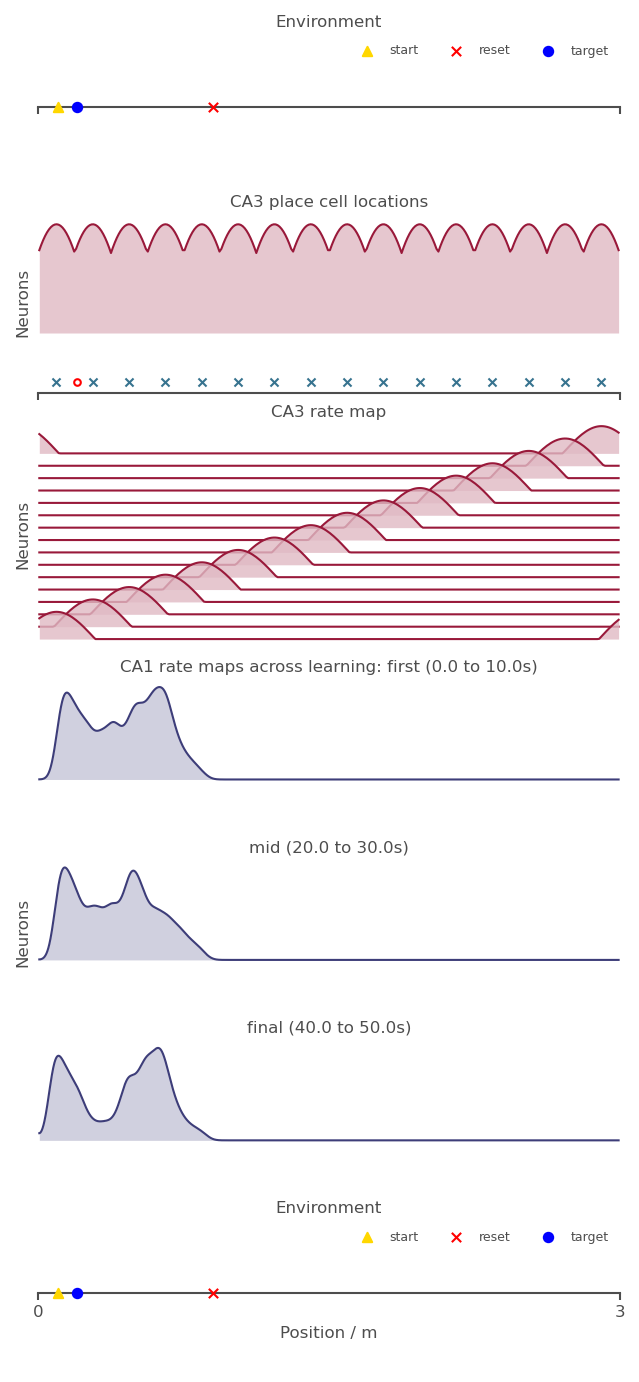

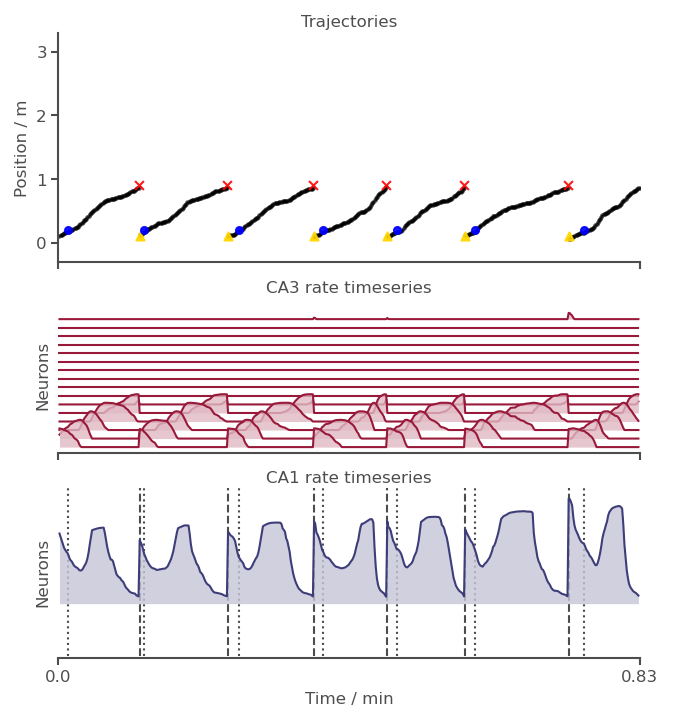

In [14]:
Env = Environment(params=env_params)

Ag = agent.ResetableAgent(Env, params=agent_params)
CA3_PCs = PlaceCells(Ag, params=CA3_PC_params)

CA1_params["input_layers"] = [CA3_PCs]
CA1s = neurons.learning_neurons.NMDALayer(Ag, params=CA1_params)
CA1s.set_learn()
CA1s.set_BTSP_learn()

for i in tqdm(range(500)):
    Ag.update()
    CA3_PCs.update()
    CA1s.update()

run_manager.plot_1D_env_info(Ag, CA3_PCs, CA1s)
run_manager.plot_1D_time_info(Ag, CA3_PCs, CA1s);

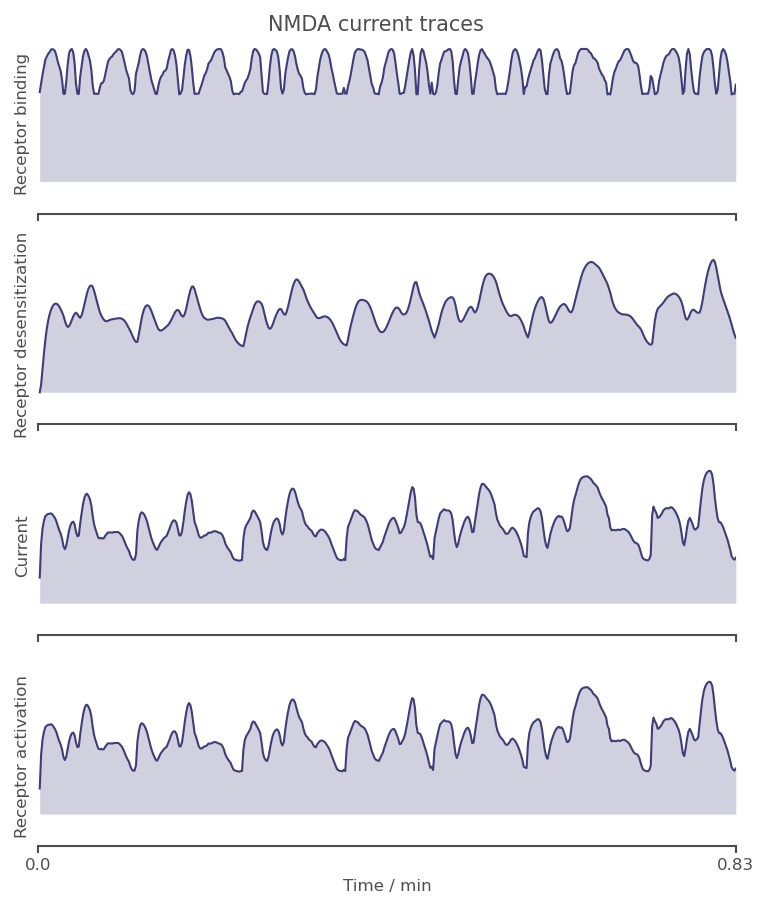

In [15]:
fig, axes = CA1s.NMDACurrent.plot_timeseries(datatypes="all")

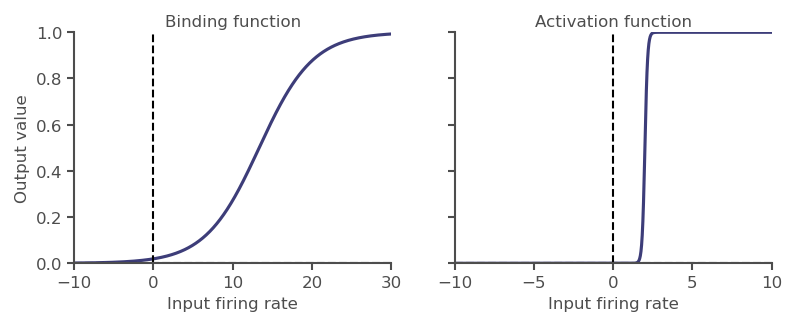

In [16]:
fig, ax = plt.subplots(1, 2, figsize=[6, 2], sharey=True)
CA1s.NMDACurrent.plot_function("binding", max_input_fr=30, fig=fig, ax=ax[0])
CA1s.NMDACurrent.plot_function("activation", fig=fig, ax=ax[1])
ax[1].set_ylabel("");

## BTSP 2-compartment independent

In [17]:
from ratinabox import Environment, PlaceCells

import importlib
importlib.reload(neurons.learning_neurons)
importlib.reload(neurons.two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [18]:
DT = params_util.DT
SCALE = params_util.SCALE_LINEAR

env_params = params_util.get_env_params(
    boundary_conditions="periodic", # to avoid receptor binding discontinuity
)

agent_params = params_util.get_agent_params(
    dt=DT,
    target_position=(SCALE - DT * 16),
)

EC_params = params_util.get_EC_params()

CA3_PC_params = params_util.get_CA3_PC_params()

CA1_params = params_util.get_CA1_params(
    n=3, environment="linear", 
    two_compartment=True, BTSP=True, 
    dend_w_init_loc=0.3,
    soma_w_init_loc=0.02,
    dend_w_init_scale=0.2,
    soma_w_init_scale=0,
    inhibit_weight=2,
    lr=1e-4,
    normalize_weights_divisively=False,
    BTSP_filter_tau=2,
    BTSP_lr_fact=30,
    single_BTSP=True,
)

In [19]:
Env = Environment(params=env_params)
Ag = agent.ResetableAgent(Env, params=agent_params)
# add objects directly
Env.objects = {"objects": np.asarray(Ag.target_position).reshape(1, 1), "object_types": np.asarray([0])}

ECs = neurons.object_neurons.ObjectCells(Ag, params=EC_params)
CA3_PCs = PlaceCells(Ag, params=CA3_PC_params)

CA1_params["dend_input_layers"] = [ECs]
CA1_params["soma_input_layers"] = [CA3_PCs]
CA1s = neurons.two_comp_neurons.TwoCompLayer(Ag, params=CA1_params)
CA1s.set_learn(soma=False, dend=False, inhibit=False)
CA1s.set_BTSP_learn(soma=True, dend=False)

for i in tqdm(range(500)):
    Ag.update()
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

100%|█████████████████████████████████████████| 500/500 [00:05<00:00, 85.61it/s]


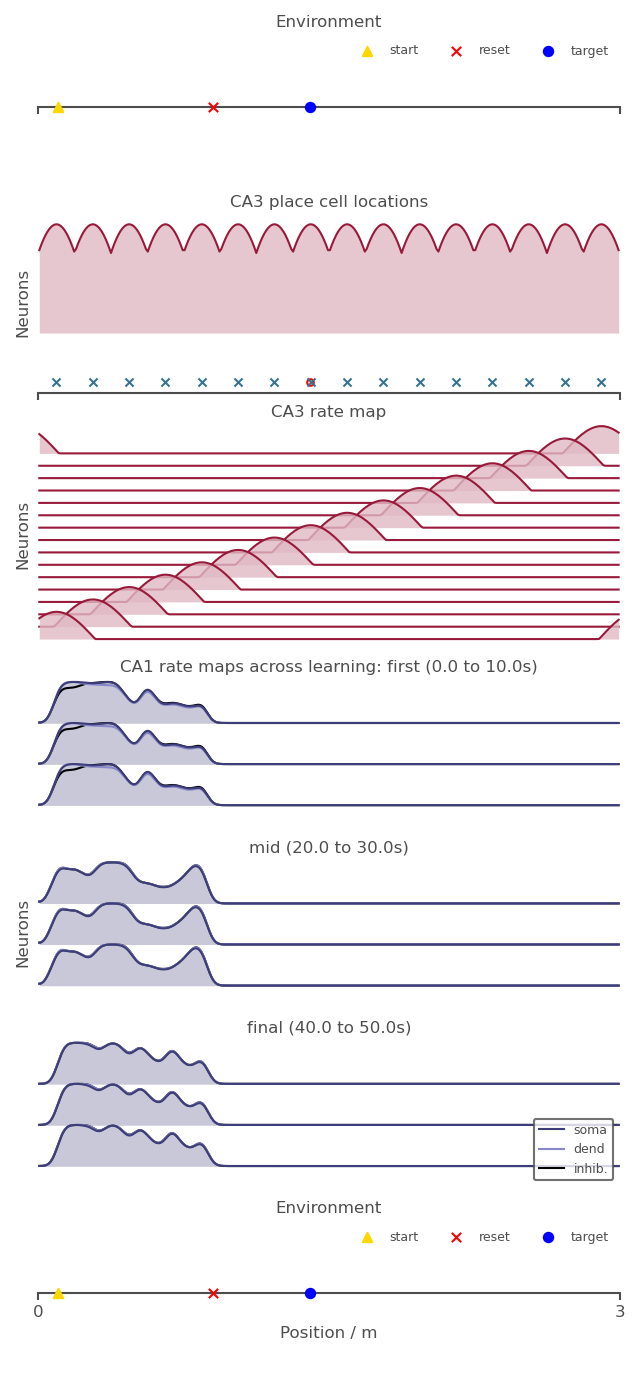

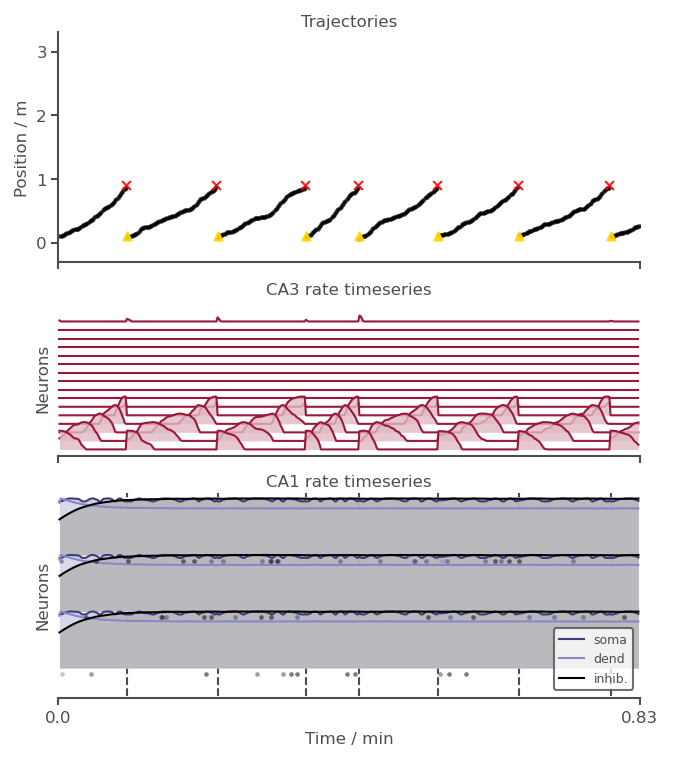

In [20]:
env_figs, env_axes = run_manager.plot_1D_env_info(Ag, CA3_PCs, CA1s);
time_figs, time_axes = run_manager.plot_1D_time_info(Ag, CA3_PCs, CA1s);

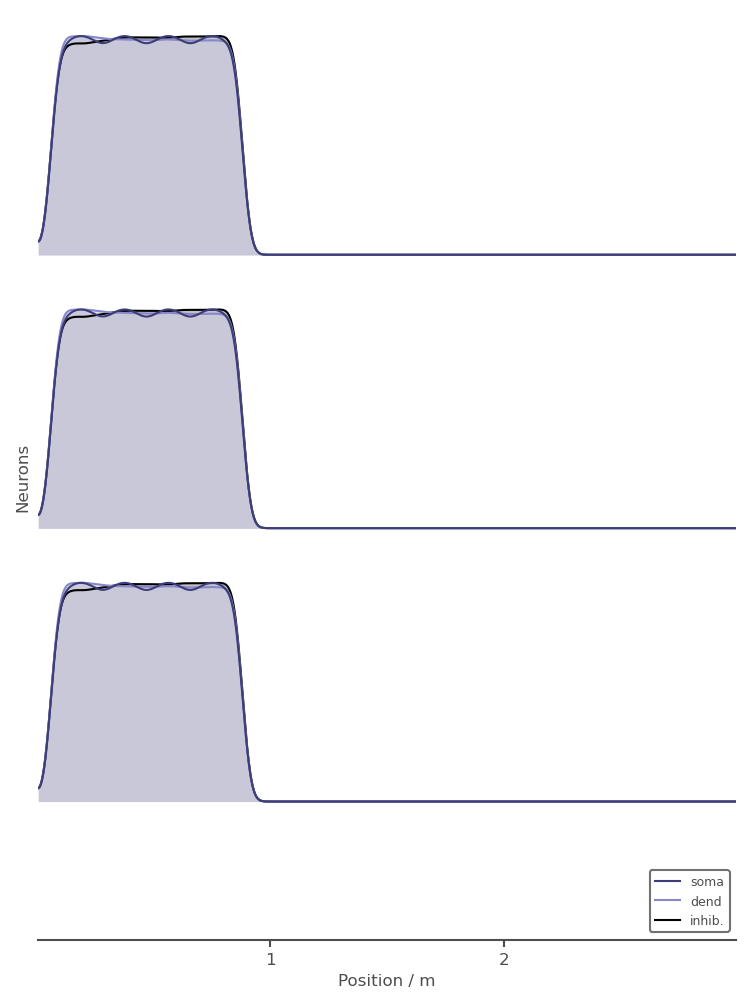

In [21]:
fig, ax = plt.subplots(figsize=[6, 8])
CA1s.plot_rate_map(fig=fig, ax=ax, t_start=-10, method="history", overlap=0.8);

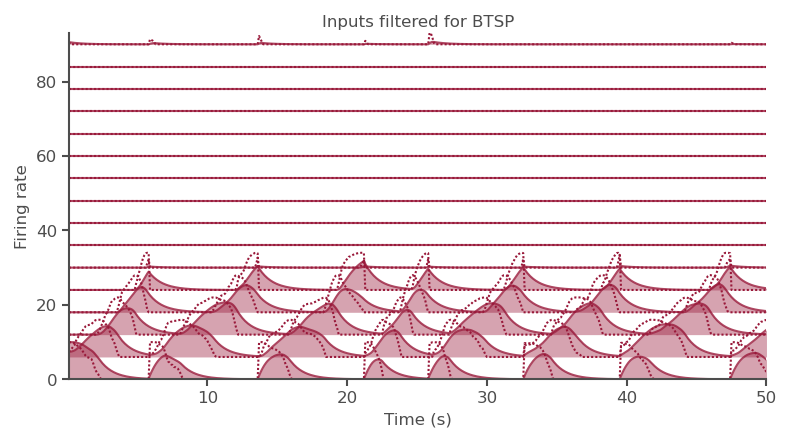

In [22]:
CA1s.SomaCompartment.plot_filtered_for_BTSP("CA3_PCs");